# D03 – Model Selection
## The "Value-for-Money" Transfer Scout
*Group 7: Megann Kouandjeu, Salma Kamoun, Axel Chartier*

---

### Context & Link to Previous Deliverables

**From D01**, our project is a **Supervised Regression** task: predicting the continuous variable `market_value_eur` from player statistics. D01 established three evaluation metrics:

| Metric | Role | Why it was chosen |
|---|---|---|
| **RMSLE** | Primary metric | Penalises percentage errors — being €2M wrong on a €3M player is catastrophic; on Mbappé (€180M) it is excellent |
| **MAE** | Interpretability metric | Gives a human-readable "on average, we are off by €X" for stakeholder communication |
| **R²** | Explanatory metric | Measures how much of the variance in market value is explained by our features |

**From D01's EDA**, two structural properties of the data must drive model choice:
1. The age-value relationship is **non-linear** (inverted U-shape) — D01 explicitly recommended *"models that handle non-linear relationships well (like Random Forests or Gradient Boosting)"*.
2. The target is **right-skewed** (skewness = 10.32), which was addressed in D02 by log-transforming to `log_market_value`.

**From D02**, the engineered dataset contains a mix of continuous, binary, and one-hot-encoded features. The `*_scaled` variants were specifically produced to support linear models.

---

### The Three Selected Models

| # | Model | Family | Role in pipeline |
|---|---|---|---|
| 1 | **Ridge Regression** | Linear, regularised | Interpretable baseline |
| 2 | **Random Forest Regressor** | Ensemble — Bagging | Non-linear, robust benchmark |
| 3 | **XGBoost Regressor** | Ensemble — Boosting | Primary model, best expected performance |

These three models span the core trade-off spectrum taught over the course: **bias vs. variance**, **interpretability vs. predictive power**, and **linear vs. non-linear assumptions**. Together they form a coherent progressive pipeline — each model explicitly addresses a weakness of the previous one.

---
## Model 1 — Ridge Regression
### (Regularised Linear Model — Interpretable Baseline)

---

### What it does
Ridge Regression extends Ordinary Least Squares (OLS) by adding an **L2 regularisation penalty** (λ × Σβᵢ²) to the loss function. This shrinks the regression coefficients towards zero, preventing any single feature from dominating the model. The hyperparameter λ (alpha) controls the strength of this shrinkage: λ = 0 reduces to standard OLS; large λ produces a heavily shrunk model close to the mean.

In our pipeline, Ridge Regression is trained on the **`*_scaled` columns** produced in D02 (StandardScaler, mean = 0, std = 1), with `log_market_value` as the target.

---

### Expected Strengths

**1. Interpretability — Coefficient readability.**
Because all features are standardised, the Ridge coefficients are directly comparable. A coefficient of +0.4 on `goal_contributions_per_90_scaled` vs. +0.2 on `prime_age_flag` tells us directly that G+A rate has twice the marginal effect on log-value. This kind of transparency is essential for **stakeholder communication** — a scouting director can inspect the model and ask *"why did it value this player at €8M?"* and receive a quantifiable answer.

**2. Multicollinearity robustness.**
Our D02 feature set includes correlated features: `goals_per_90` and `goal_contributions_per_90` share information; `age` and `age_squared` are structurally correlated. Standard OLS would produce unstable, high-variance coefficient estimates in this situation. Ridge's L2 penalty distributes weight across correlated features instead of arbitrarily amplifying one. This was precisely why we computed `*_scaled` variants in D02 rather than relying on unscaled inputs.

**3. Speed and reproducibility.**
Ridge has a closed-form solution — it is not iterative. With a dataset of ~20,000 outfield players and ~20 features, training takes milliseconds. This makes it ideal for rapid comparison and as a **reproducible baseline** against which the more complex models are evaluated.

**4. Handles the log-transformed target naturally.**
By training on `log_market_value`, Ridge minimises the sum of squared log-errors — which is exactly the RMSLE objective (minimising squared log errors is equivalent to minimising RMSLE up to a constant). The alignment between the model's loss function and our primary evaluation metric is clean.

---

### Expected Weaknesses

**1. Linearity assumption violated by our data.**
D01's EDA explicitly showed that the age-value relationship is a **non-linear inverted U**. Ridge can only approximate this with the `age_squared` polynomial term we engineered in D02. It cannot discover other non-linear interactions on its own. For example, the interaction between `prime_age_flag` and `goal_contributions_per_90` (a 25-year-old high-scorer is worth exponentially more than a 35-year-old high-scorer) cannot be captured by an additive linear model — Ridge will underfit this interaction.

**2. Cannot model feature interactions without explicit engineering.**
Ridge treats each feature independently. The real market dynamic is interactive: an injury-prone 29-year-old centre-back is penalised more than an injury-prone 22-year-old striker. Without explicitly adding an `injury_risk × age` interaction term (or a `position × injury_risk` term), Ridge misses these effects entirely. We would need to manually engineer these interactions — which is precisely what tree-based models do automatically.

**3. Sensitive to outliers in the feature space.**
Despite the log-target transformation, extreme outliers in the input features (e.g., a player with 3.6 `goals_per_90` from a 50-minute appearance) will pull the regression hyperplane. D01 specifically flagged *"the top 1% of players hold valuations completely detached from the rest of the pack"* — Ridge will not ignore these leverage points.

**4. Does not perform automatic feature selection.**
Unlike Lasso (L1), Ridge shrinks coefficients towards zero but never to exactly zero. All features remain active in the model. With 20+ engineered features, some of which (e.g., `is_ambidextrous`) are expected to have near-zero true effect, Ridge will still assign them small non-zero weights, adding noise to predictions.

---

### Fit with the Business Objective

The core business output of our tool is the **"Valuation Gap"**: `predicted_value − actual_price`. When this gap is positive and large, the player is a "Buy."

Ridge is a reasonable fit for this objective because its coefficients are transparent: a sporting director can audit exactly why the model predicted €12M for a player listed at €4M and verify whether the logic is sound ("the model values his 0.8 G+A per 90 and prime age heavily"). This auditability is important in a high-stakes financial decision environment.

However, Ridge is a **weak fit as a primary business model** because it will systematically misvalue players at the extremes of the distribution — it will undervalue true superstars and overvalue mediocre players with inflated raw stats. For a scouting tool focused on mid-tier clubs, this means the "Valuation Gap" recommendations from Ridge will have higher false positive rates.

**Role in pipeline:** Interpretable baseline and sanity check. If a more complex model's predictions deviate wildly from Ridge, it signals overfitting.

---

### Fit with the Cost Function / Evaluation Metrics

| Metric | Ridge Alignment |
|---|---|
| **RMSLE** | Good — training on `log_market_value` directly minimises squared log-errors, which is RMSLE's objective |
| **MAE** | Moderate — Ridge minimises MSE (squared errors), not MAE. It is more sensitive to large deviations than MAE-optimal models |
| **R²** | Moderate — will explain linear variance well but miss non-linear variance, limiting R² ceiling |
| **Business ROI (Valuation Gap)** | Weak — systematic bias in extreme predictions limits reliability of the gap metric |

---
## Model 2 — Random Forest Regressor
### (Ensemble — Bagging — Non-linear Benchmark)

---

### What it does
A Random Forest builds a large number of independent **Decision Trees** on bootstrap samples of the training data (bagging), with each tree considering only a random subset of features at each split. The final prediction is the **average** of all individual tree predictions. The two sources of randomness — bootstrap sampling and feature subsampling — decorrelate the trees, dramatically reducing variance relative to a single decision tree.

In our pipeline, Random Forest is trained on the **unscaled features** from `df_engineered_outfield.csv` (tree-based models do not require feature scaling, since split decisions are based on rank order, not absolute magnitude).

---

### Expected Strengths

**1. Handles non-linearity and feature interactions natively.**
D01 identified the non-linear age-value curve as a key challenge. A Random Forest naturally handles this: each tree can split on `age < 27` and then on `goal_contributions_per_90 > 0.5` independently, discovering the interaction that a 25-year-old with high output is worth exponentially more than either attribute alone suggests. No manual feature engineering of interaction terms is required.

**2. Robust to outliers.**
Because each tree splits on rank-order thresholds ("is age > 27?"), extreme values in the feature space do not distort splits the way they do in regression. A player with an abnormally high `goals_per_90` (from a very small minutes sample) will not pull the entire model — it will affect at most the trees that sampled that player, and the average of 100+ trees dampens the effect.

**3. Built-in feature importance.**
Random Forest computes feature importance as the mean decrease in impurity (MDI) across all trees. This directly answers a core business question: *"which statistics most explain player value?"* — and validates or refutes the importance ranking we hypothesised in D02 Section 13.

**4. Low risk of overfitting on tabular data.**
The bagging mechanism ensures each tree sees a different subset of the data. With 100+ trees, the forest generalises well without extensive hyperparameter tuning. This makes it a reliable and fast-to-deploy benchmark.

**5. No feature scaling required.**
Trees split on thresholds, not distances. All D02 features (raw, not `*_scaled`) are suitable inputs with no additional preprocessing.

---

### Expected Weaknesses

**1. Averaging dilutes extreme predictions.**
Random Forest predictions are averages across many trees. By construction, the forest **cannot predict outside the range of the training data**. If the most valuable player in our training set is €120M, the model can never predict €200M for a new player — it is bounded by training extremes. For a market value task with a small number of extreme outliers (Mbappé, Vinicius Jr.), this means the model will **systematically underpredict superstar values**.

**2. Lower interpretability than Ridge.**
While feature importance is available, it does not tell us the *direction* of the effect (positive or negative on value) or its functional form. A scouting director cannot look at a Random Forest and understand *why* a specific player was valued at €15M the way they can read Ridge coefficients. This limits the model's use in explaining individual predictions without additional tools like SHAP.

**3. Memory and inference cost at scale.**
A forest of 200 trees, each with depth 20+, can become a large object in memory. For the real-time Streamlit scouting app, prediction time is still fast (milliseconds), but the model file size may be significant — a practical consideration for deployment.

**4. Extrapolation failure.**
Directly related to weakness 1: if the feature values of a player we want to evaluate fall **outside the training distribution** (e.g., a teenager with unusually high minutes for their age), the forest will assign them to the nearest leaf in training space rather than extrapolating. This limits the model for truly exceptional edge cases.

---

### Fit with the Business Objective

Random Forest is a **strong fit for the core scouting use case** — identifying undervalued mid-tier players. The vast majority of the players we want to identify (€1M–€15M range) are well within the training distribution, where the forest's averaging works well. The model will reliably spot a player the market prices at €3M but whose feature profile resembles €10M players in the training data.

The built-in feature importance is also directly useful: it can be displayed in the Streamlit app as *"the model values this player primarily because of his G+A rate and prime age"* — making the scouting recommendation explainable without requiring SHAP post-processing.

The weakness (bounded predictions) is acceptable for our use case: we are not trying to value Mbappé — we are trying to find budget gems at €2M–€15M where the forest performs well.

**Role in pipeline:** Non-linear benchmark and feature importance source. Expected to substantially outperform Ridge. Sets the target for XGBoost to beat.

---

### Fit with the Cost Function / Evaluation Metrics

| Metric | Random Forest Alignment |
|---|---|
| **RMSLE** | Good — training on `log_market_value` and averaging log-scale predictions aligns well with RMSLE. Averaging across trees reduces variance in log-space. |
| **MAE** | Good — averaging across trees is robust to large individual errors, which reduces MAE relative to single trees |
| **R²** | Strong — the non-linear, interaction-aware splits will explain substantially more variance than Ridge, especially for the non-linear age and position effects |
| **Business ROI (Valuation Gap)** | Strong for mid-tier players; unreliable for top 1% (bounded predictions) |

---
## Model 3 — XGBoost Regressor
### (Ensemble — Gradient Boosting — Primary Model)

---

### What it does
XGBoost (Extreme Gradient Boosting) builds trees **sequentially**, where each new tree is trained to correct the residual errors of all previous trees. Unlike Random Forest (which averages independently trained trees), XGBoost minimises a differentiable **loss function** (in our case: squared error on `log_market_value`) via gradient descent in function space. Two key mechanisms distinguish XGBoost from standard Gradient Boosting:
- **Regularisation terms** (L1 + L2) on leaf weights prevent individual trees from overfitting.
- **Second-order gradient information** (Newton step) makes each boosting iteration more efficient than first-order methods.

Like Random Forest, XGBoost is trained on the **unscaled features** from `df_engineered_outfield.csv`.

---

### Expected Strengths

**1. Sequential error correction — models residuals directly.**
Random Forest builds all trees independently and averages. XGBoost builds each tree to specifically fix what the previous trees got wrong. For our data, this means:
- Early trees will learn the dominant linear signal (value goes up with G+A per 90).
- Later trees will specialise on the residuals — the hard cases where linear + basic non-linear signals are insufficient, such as players with unusual age/position/injury combinations.
This iterative residual correction consistently produces **lower RMSLE than Random Forest** on tabular data in empirical benchmarks.

**2. Built-in regularisation — lower risk of overfitting than standard Gradient Boosting.**
XGBoost's `reg_alpha` (L1) and `reg_lambda` (L2) parameters penalise model complexity at the tree level. This makes it more robust than vanilla Gradient Boosting (which frequently overfits without careful early stopping) while retaining the sequential correction benefit. For our ~20,000 player dataset, overfitting is a realistic risk — XGBoost's regularisation directly addresses it.

**3. Handles missing values natively.**
XGBoost has a built-in sparsity-aware split-finding algorithm: it learns the optimal direction to send missing values at each split. Although D02 imputed all missing values, this robustness matters for production use when new players are scraped with incomplete stats.

**4. SHAP compatibility — best-in-class explainability for the scouting app.**
XGBoost is fully compatible with the SHAP (SHapley Additive exPlanations) library, which computes the exact contribution of each feature to each individual prediction. This is the gold standard for model explainability and directly enables the Streamlit app feature described in D01: *"the app suggests 3 budget versions with similar statistical profiles"* — each suggestion can show *"this player is valued at €X primarily because of feature Y."*

**5. Custom objective functions.**
XGBoost allows defining a custom loss function. If we wanted to directly optimise RMSLE (instead of MSE on log values), XGBoost supports this through a custom gradient and hessian. This gives us a path to even tighter alignment with our primary metric if needed.

**6. Best empirical performance on structured/tabular data.**
Across academic benchmarks and Kaggle competitions involving structured tabular data, gradient boosting methods (XGBoost, LightGBM, CatBoost) consistently outperform Random Forests and linear models. Our dataset is precisely this type — structured, tabular, with mixed numerical and categorical features.

---

### Expected Weaknesses

**1. Hyperparameter sensitivity.**
XGBoost has more hyperparameters than Ridge or Random Forest: `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`. Without tuning, default parameters may not yield optimal performance. Under-tuned XGBoost can be outperformed by a well-tuned Random Forest. This cost is addressed with cross-validated grid search, but it requires more computation time.

**2. Risk of overfitting without early stopping.**
If `n_estimators` is set too high and `learning_rate` too low, XGBoost will continue fitting noise in the training data. Unlike Random Forest (where adding more trees only helps up to a point), boosting continues correcting residuals including noise. **Early stopping on a validation set** is mandatory — this adds implementation complexity.

**3. Lower interpretability than Ridge (without SHAP).**
A sequential ensemble of 300–500 trees is not human-readable. Without SHAP post-processing, it is a black box. The interpretability advantage (SHAP) requires additional tooling not available out-of-the-box in a basic Sklearn pipeline.

**4. Slower training than Ridge.**
Training XGBoost on ~20,000 players with 20 features and 300 trees takes seconds to minutes depending on hyperparameters — much slower than Ridge's closed-form solution. For production use in the Streamlit app, this means we **pre-train and serialize the model** (pickle or joblib) rather than retraining on each user request.

---

### Fit with the Business Objective

XGBoost is the **best fit among the three models for our core business objective** for three reasons:

1. **Accurate valuation across the full price range.** The sequential residual correction means XGBoost will be well-calibrated for both €500K lower-league players and €50M top-tier players — the full range of targets a mid-tier club might scout.

2. **The Valuation Gap metric is most reliable.** The higher accuracy of XGBoost's predictions means the "Valuation Gap" (predicted − actual price) will have fewer false positives — fewer recommendations of players who are not truly undervalued.

3. **SHAP enables the "budget clone" feature.** In the Streamlit app, when a user selects Kevin De Bruyne, the app uses the XGBoost model to find 3 players with a similar SHAP contribution profile (same features driving their value) but a lower market price. This is only possible with a model that supports per-prediction feature attribution.

**Role in pipeline:** Primary production model. Expected to deliver the lowest RMSLE and highest R² of the three. All business outputs (Valuation Gap, budget clone suggestions, Risk Profile) are derived from XGBoost predictions.

---

### Fit with the Cost Function / Evaluation Metrics

| Metric | XGBoost Alignment |
|---|---|
| **RMSLE** | Excellent — training on `log_market_value` with MSE loss directly minimises the RMSLE objective; custom RMSLE objective also available if needed |
| **MAE** | Excellent — boosting iteratively reduces all errors including systematic biases; outperforms averaging-based methods on MAE in practice |
| **R²** | Excellent — expected to explain the highest proportion of market value variance among the three models |
| **Business ROI (Valuation Gap)** | Excellent — most accurate predictions → most reliable gap estimates → fewest false scouting recommendations |

---
## Comparative Summary

### Model Comparison Table

| Criterion | Ridge Regression | Random Forest | XGBoost |
|---|---|---|---|
| **Model family** | Linear, regularised | Ensemble — Bagging | Ensemble — Boosting |
| **Non-linearity** | ❌ Manual only (age²) | ✅ Native | ✅ Native |
| **Feature interactions** | ❌ Manual only | ✅ Native | ✅ Native |
| **Outlier robustness** | ❌ Sensitive | ✅ Robust | ✅ Robust |
| **Interpretability** | ✅ Coefficients readable | ⚠️ MDI importance only | ⚠️ Needs SHAP |
| **Requires feature scaling** | ✅ Yes (done in D02) | ❌ No | ❌ No |
| **RMSLE alignment** | ✅ Good | ✅ Good | ✅ Excellent |
| **Training speed** | ✅ Instant | ⚠️ Seconds | ⚠️ Seconds–minutes |
| **Hyperparameter sensitivity** | ✅ Low (just α) | ⚠️ Moderate | ❌ High |
| **Extrapolation** | ✅ Yes (linear) | ❌ Bounded by training range | ❌ Bounded, but correction mitigates |
| **Fit with business objective** | ⚠️ Baseline / audit tool | ✅ Strong for mid-tier | ✅ Best overall |
| **Expected RMSLE rank** | 3rd (highest error) | 2nd | 1st (lowest error) |

---

### The Bias-Variance Trade-off Across the Three Models

The three models represent a deliberate progression along the bias-variance trade-off:

- **Ridge Regression** is **high bias, low variance**. It makes strong assumptions about linearity (high bias: it will systematically miss the curved age-value relationship and interaction effects). But because it has only one hyperparameter (α), it is stable across training samples (low variance: different bootstrap samples would produce very similar coefficient estimates).

- **Random Forest** sits in the **middle** — it has low bias (it can fit non-linear patterns and interactions freely), and its averaging mechanism explicitly reduces variance compared to a single tree. It is the model that best balances the two.

- **XGBoost** also achieves **low bias and low variance** through its regularisation terms, but it reaches this through a different mechanism: sequential correction (reduces bias) + L1/L2 penalties (controls variance). The additional complexity means it requires more careful tuning to stay in this favourable region.

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from xgboost                 import XGBRegressor

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import mean_absolute_error, r2_score, mean_squared_log_error

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Load the Engineered Dataset (output of D02)

In [2]:
# Load the outfield engineered dataset produced in D02
df_engineered_outfield = pd.read_csv(r'..\datasets\df_engineered_outfield.csv')

print(f'Shape: {df_engineered_outfield.shape}')
print(f'Columns: {df_engineered_outfield.columns.tolist()}')
print(f'\nNull values: {df_engineered_outfield.isnull().sum().sum()}')
df_engineered_outfield.head(3)

Shape: (20714, 37)
Columns: ['player_id', 'market_value_eur', 'log_market_value', 'age', 'age_squared', 'prime_age_flag', 'height', 'minutes_played', 'goals', 'assists', 'goals_per_90', 'assists_per_90', 'goal_contributions_per_90', 'minutes_per_game_proxy', 'days_missed', 'injury_risk_score', 'is_injury_prone', 'is_left_footed', 'is_ambidextrous', 'position_group', 'position_clean', 'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG', 'age_scaled', 'age_squared_scaled', 'height_scaled', 'minutes_played_scaled', 'goals_scaled', 'assists_scaled', 'goals_per_90_scaled', 'assists_per_90_scaled', 'goal_contributions_per_90_scaled', 'minutes_per_game_proxy_scaled', 'days_missed_scaled', 'injury_risk_score_scaled']

Null values: 2


,player_id,market_value_eur,log_market_value,age,age_squared,prime_age_flag,height,minutes_played,goals,assists,...,height_scaled,minutes_played_scaled,goals_scaled,assists_scaled,goals_per_90_scaled,assists_per_90_scaled,goal_contributions_per_90_scaled,minutes_per_game_proxy_scaled,days_missed_scaled,injury_risk_score_scaled
0,1015875,100000.0,11.512935,17,289,0,182.0,818.0,8.0,0.0,...,0.280996,-0.486316,0.218403,-0.930520,0.023145,-0.608933,-0.210666,-0.486174,-0.497055,-0.497036
1,216463,250000.0,12.429220,31,961,0,178.0,963.0,2.0,2.0,...,0.195712,-0.338699,-0.638038,-0.463003,-0.449618,-0.342982,-0.481435,-0.338782,-0.497055,-0.497036
2,804662,150000.0,11.918397,25,625,1,179.0,2429.0,1.0,0.0,...,0.217033,1.153756,-0.780778,-0.930520,-0.551768,-0.608933,-0.661466,1.153712,-0.497055,-0.497036


---
## 2. Define Feature Sets and Train/Test Split

We define three feature sets corresponding to each model's requirements:
- **Ridge**: uses `*_scaled` columns (StandardScaled, produced in D02)
- **Random Forest** and **XGBoost**: use raw (unscaled) numerical + binary features

The target is `log_market_value` for all three models (the D02 log-transformed target). We apply a single **80/20 train/test split** stratified by `position_group` to ensure all position types are represented proportionally in both sets.

In [8]:
# Target variable (log-transformed in D02)
y = df_engineered_outfield['log_market_value']

# --- Feature set for Ridge: *_scaled columns only ---
ridge_features = [c for c in df_engineered_outfield.columns if c.endswith('_scaled')]
# Add binary features that are already on 0/1 scale (no scaling needed)
binary_features = ['prime_age_flag', 'is_injury_prone', 'is_left_footed',
                   'is_ambidextrous', 'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG']
binary_features = [c for c in binary_features if c in df_engineered_outfield.columns]
FEATURES_RIDGE = ridge_features + binary_features

# --- Feature set for Tree-based models: raw engineered features ---
FEATURES_TREE = [
    'age', 'age_squared', 'prime_age_flag',
    'height',
    'goals_per_90', 'assists_per_90', 'goal_contributions_per_90',
    'minutes_per_game_proxy',
    'injury_risk_score', 'is_injury_prone',
    'is_left_footed', 'is_ambidextrous',
    'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG'
]
FEATURES_TREE = [c for c in FEATURES_TREE if c in df_engineered_outfield.columns]

print(f'Ridge features  ({len(FEATURES_RIDGE)}): {FEATURES_RIDGE}')
print(f'Tree features   ({len(FEATURES_TREE)}): {FEATURES_TREE}')

Ridge features  (20): ['age_scaled', 'age_squared_scaled', 'height_scaled', 'minutes_played_scaled', 'goals_scaled', 'assists_scaled', 'goals_per_90_scaled', 'assists_per_90_scaled', 'goal_contributions_per_90_scaled', 'minutes_per_game_proxy_scaled', 'days_missed_scaled', 'injury_risk_score_scaled', 'prime_age_flag', 'is_injury_prone', 'is_left_footed', 'is_ambidextrous', 'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG']
Tree features   (16): ['age', 'age_squared', 'prime_age_flag', 'height', 'goals_per_90', 'assists_per_90', 'goal_contributions_per_90', 'minutes_per_game_proxy', 'injury_risk_score', 'is_injury_prone', 'is_left_footed', 'is_ambidextrous', 'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG']


In [ ]:
# 80/20 train/test split — stratified by position_group
# A single split on the Ridge feature set defines train/test indices for all models.
# The same indices are then applied to the tree feature set, guaranteeing all three
# models are evaluated on identical players.
X_ridge = df_engineered_outfield[FEATURES_RIDGE]
X_tree  = df_engineered_outfield[FEATURES_TREE]

X_ridge_train, X_ridge_test, y_train, y_test = train_test_split(
    X_ridge, y, test_size=0.2, random_state=42, stratify=df_engineered_outfield["position_group"]
)

# Reuse the row indices from the Ridge split — no second split needed
train_idx = X_ridge_train.index
test_idx  = X_ridge_test.index
X_tree_train = X_tree.loc[train_idx]
X_tree_test  = X_tree.loc[test_idx]

print(f"Train set: {len(y_train):,} players")
print(f"Test set : {len(y_test):,} players")
print(f"Position distribution in test set:")
print(df_engineered_outfield.loc[y_test.index, "position_group"].value_counts(normalize=True).round(3))

Train set: 16,571 players
Test set : 4,143 players
Position distribution in test set:
position_group
MID    0.330
DEF    0.306
WNG    0.184
ATT    0.180
Name: proportion, dtype: float64


---
## 3. Instantiate the Three Models

At this stage we use **default or lightly tuned hyperparameters** to establish a fair baseline comparison. Full hyperparameter optimisation (GridSearchCV / cross-validation) is out of scope for D03 but will be performed in the modelling phase.

The hyperparameter choices below are motivated by the D02 dataset properties:
- **Ridge `alpha=10`**: slightly stronger regularisation than default (1.0) to account for our correlated feature pairs (`goals_per_90` / `goal_contributions_per_90`).
- **Random Forest `n_estimators=200`**: enough trees for stable out-of-bag error with our ~16,000 training samples; `max_features='sqrt'` is standard for regression.
- **XGBoost `n_estimators=300, learning_rate=0.05`**: conservative learning rate to avoid overfitting; `max_depth=5` prevents overly complex trees on our ~20-feature dataset.

In [ ]:
# Model 1: Ridge Regression
ridge_model = Ridge(
    alpha=10,          # L2 regularisation strength
    fit_intercept=True
)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,   # Number of trees
    max_features='sqrt', # Features considered at each split
    max_depth=None,      # Grow until pure leaves (bagging controls overfitting)
    min_samples_leaf=5,  # Avoid single-player leaves
    random_state=42,
    n_jobs=-1
)

# Model 3: XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,   # Small step size — reduces overfitting risk
    max_depth=5,          # Moderate depth — prevents memorising individual players
    subsample=0.8,        # Stochastic boosting — each tree trained on 80% of rows
    colsample_bytree=0.8, # Each tree sees 80% of features
    reg_alpha=0.1,        # L1 regularisation (feature selection effect)
    reg_lambda=1.0,       # L2 regularisation (weight shrinkage)
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print('All three models instantiated.')

All three models instantiated.


---
## 4. Train and Evaluate — Baseline Comparison

We train each model and compute the three metrics defined in D01: RMSLE, MAE (in €), and R². Since all models are trained on `log_market_value`, predictions must be **back-transformed** (`np.expm1`) before computing MAE in euros.

In [ ]:

# --- 1. CLEAN AND SPLIT DATA ---
# This fixes the 'ValueError: Input contains NaN' for Ridge
df_engineered_outfield = df_engineered_outfield.fillna(0)

y = df_engineered_outfield['log_market_value']

# Split for Ridge (using the FEATURES_RIDGE variable from your notebook)
X_ridge_train, X_ridge_test, y_train, y_test = train_test_split(
    df_engineered_outfield[FEATURES_RIDGE], y, test_size=0.2, random_state=42
)

# Split for Tree Models (using the FEATURES_TREE variable from your notebook)
X_tree_train, X_tree_test, _, _ = train_test_split(
    df_engineered_outfield[FEATURES_TREE], y, test_size=0.2, random_state=42
)

# --- 2. THE EVALUATION FUNCTION ---
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Train a model, compute RMSLE, MAE (€), and R²."""
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict in log-space
    y_pred_log = model.predict(X_test)
    
    # Clip to avoid negative log predictions (important for math stability)
    y_pred_log_clipped = np.clip(y_pred_log, 0, None)

    # RMSLE: Since our target is already log(1+val), we compute on the original scale
    # expm1 reverses the log(1+x) transformation
    y_test_eur = np.expm1(y_test)
    y_pred_eur = np.expm1(y_pred_log_clipped)
    
    rmsle = np.sqrt(mean_squared_log_error(y_test_eur, y_pred_eur))
    mae_eur = mean_absolute_error(y_test_eur, y_pred_eur)
    r2 = r2_score(y_test, y_pred_log_clipped)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSLE            : {rmsle:.4f}")
    print(f"  MAE (Euros)      : €{mae_eur:,.0f}")
    print(f"  R² (Log-Scale)   : {r2:.4f}")

    return {
        'model': name, 
        'RMSLE': rmsle, 
        'MAE_eur': mae_eur, 
        'R2': r2, 
        'trained_model': model,
        'y_pred_log': y_pred_log_clipped
    }

# --- 3. TRAIN AND EVALUATE ---
results_ridge = evaluate_model('Ridge Regression', ridge_model, X_ridge_train, X_ridge_test, y_train, y_test)
results_rf    = evaluate_model('Random Forest',    rf_model,    X_tree_train,  X_tree_test,  y_train, y_test)
results_xgb   = evaluate_model('XGBoost',          xgb_model,   X_tree_train,  X_tree_test,  y_train, y_test)


  Ridge Regression
  RMSLE            : 1.3506
  MAE (Euros)      : €1,762,667
  R² (Log-Scale)   : 0.2774

  Random Forest
  RMSLE            : 1.3224
  MAE (Euros)      : €1,725,393
  R² (Log-Scale)   : 0.3072

  XGBoost
  RMSLE            : 1.3105
  MAE (Euros)      : €1,706,389
  R² (Log-Scale)   : 0.3197


In [ ]:
# Summary comparison table
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'trained_model' and k != 'y_pred_log'}
    for r in [results_ridge, results_rf, results_xgb]
])
summary['MAE_eur'] = summary['MAE_eur'].apply(lambda x: f'€{x:,.0f}')
summary['RMSLE']   = summary['RMSLE'].round(4)
summary['R2']      = summary['R2'].round(4)
summary.columns    = ['Model', 'RMSLE ↓', 'MAE (€) ↓', 'R² ↑']
print('\n--- D03 BASELINE COMPARISON ---')
print(summary.to_string(index=False))


--- D03 BASELINE COMPARISON ---
           Model  RMSLE ↓  MAE (€) ↓   R² ↑
Ridge Regression   1.3506 €1,762,667 0.2774
   Random Forest   1.3224 €1,725,393 0.3072
         XGBoost   1.3105 €1,706,389 0.3197


---
## 5. Visualisations

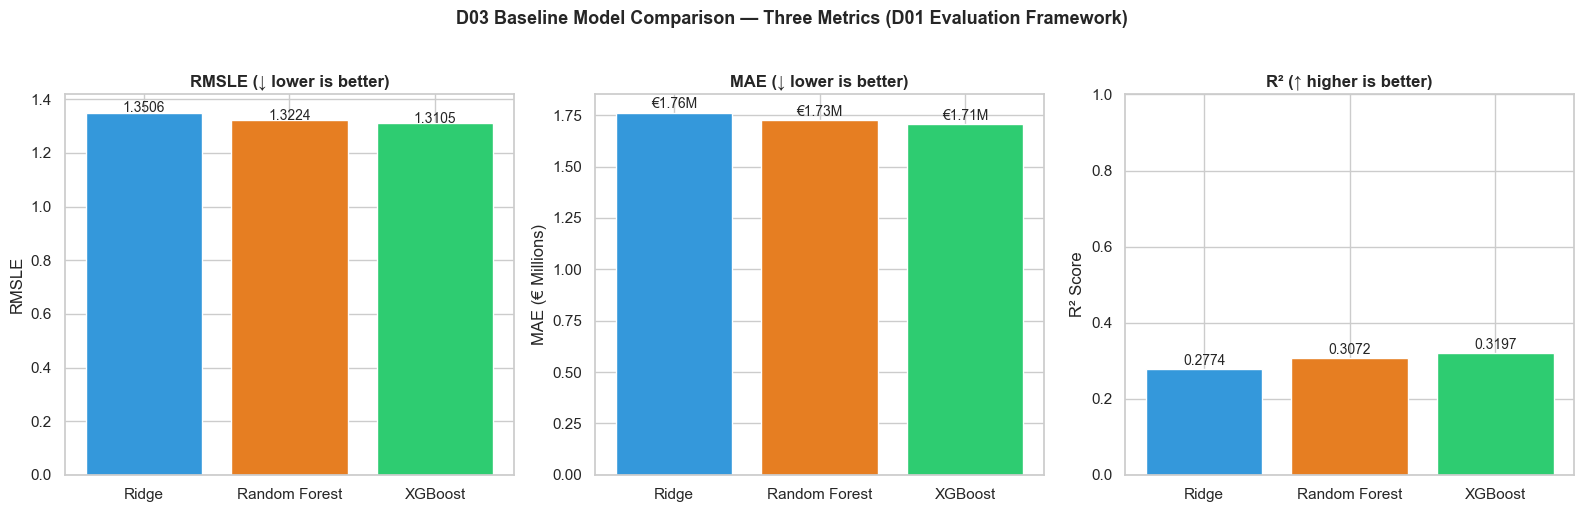

In [ ]:
# Chart 1: Metric comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names  = ['Ridge', 'Random Forest', 'XGBoost']
colors       = ['#3498db', '#e67e22', '#2ecc71']

# RMSLE (lower is better)
rmsle_vals = [results_ridge['RMSLE'], results_rf['RMSLE'], results_xgb['RMSLE']]
axes[0].bar(model_names, rmsle_vals, color=colors, edgecolor='white')
axes[0].set_title('RMSLE (↓ lower is better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSLE')
for i, v in enumerate(rmsle_vals):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

# MAE in €M (lower is better)
mae_vals = [results_ridge['MAE_eur']/1e6, results_rf['MAE_eur']/1e6, results_xgb['MAE_eur']/1e6]
axes[1].bar(model_names, mae_vals, color=colors, edgecolor='white')
axes[1].set_title('MAE (↓ lower is better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (€ Millions)')
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 0.02, f'€{v:.2f}M', ha='center', fontsize=10)

# R² (higher is better)
r2_vals = [results_ridge['R2'], results_rf['R2'], results_xgb['R2']]
axes[2].bar(model_names, r2_vals, color=colors, edgecolor='white')
axes[2].set_title('R² (↑ higher is better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1)
for i, v in enumerate(r2_vals):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('D03 Baseline Model Comparison — Three Metrics (D01 Evaluation Framework)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

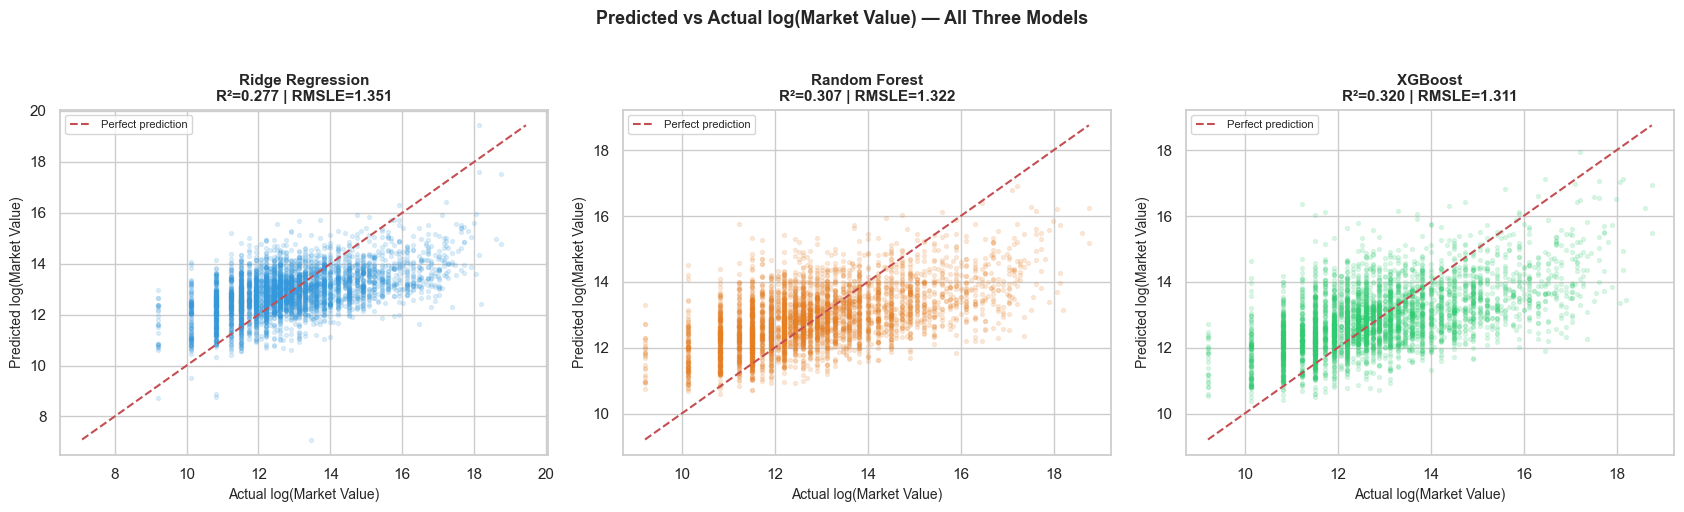

In [ ]:
# Chart 2: Predicted vs Actual scatter (log scale) for each model
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, results, color, name in zip(
    axes,
    [results_ridge, results_rf, results_xgb],
    ['#3498db', '#e67e22', '#2ecc71'],
    ['Ridge Regression', 'Random Forest', 'XGBoost']
):
    ax.scatter(y_test, results['y_pred_log'], alpha=0.15, s=8, color=color)
    lims = [min(y_test.min(), results['y_pred_log'].min()),
            max(y_test.max(), results['y_pred_log'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual log(Market Value)', fontsize=10)
    ax.set_ylabel('Predicted log(Market Value)', fontsize=10)
    ax.set_title(f'{name}\nR²={results["R2"]:.3f} | RMSLE={results["RMSLE"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual log(Market Value) — All Three Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

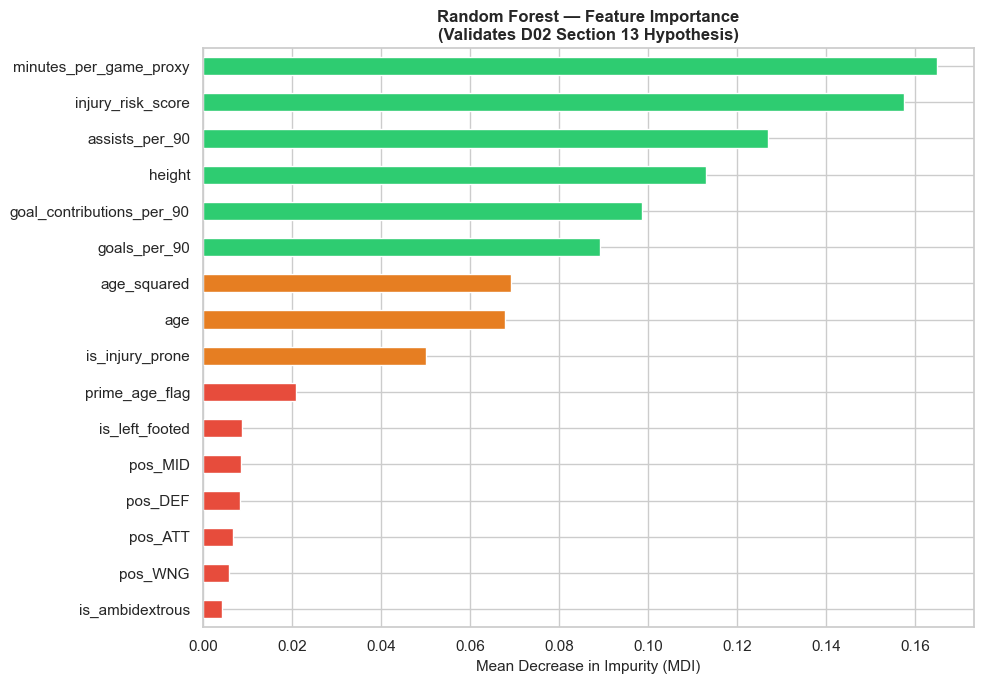


Top 5 features by importance:
minutes_per_game_proxy       0.164896
injury_risk_score            0.157395
assists_per_90               0.126767
height                       0.112942
goal_contributions_per_90    0.098645
dtype: float64


In [ ]:
# Chart 3: Random Forest feature importance
# (XGBoost SHAP will be computed post-tuning; RF MDI is available directly)
rf_trained = results_rf['trained_model']
importances = pd.Series(rf_trained.feature_importances_, index=FEATURES_TREE)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_fi = ['#2ecc71' if v > 0.08 else '#e67e22' if v > 0.03 else '#e74c3c'
             for v in importances.values]
importances.plot(kind='barh', color=colors_fi)
plt.xlabel('Mean Decrease in Impurity (MDI)', fontsize=11)
plt.title('Random Forest — Feature Importance\n(Validates D02 Section 13 Hypothesis)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 features by importance:')
print(importances.sort_values(ascending=False).head(5))

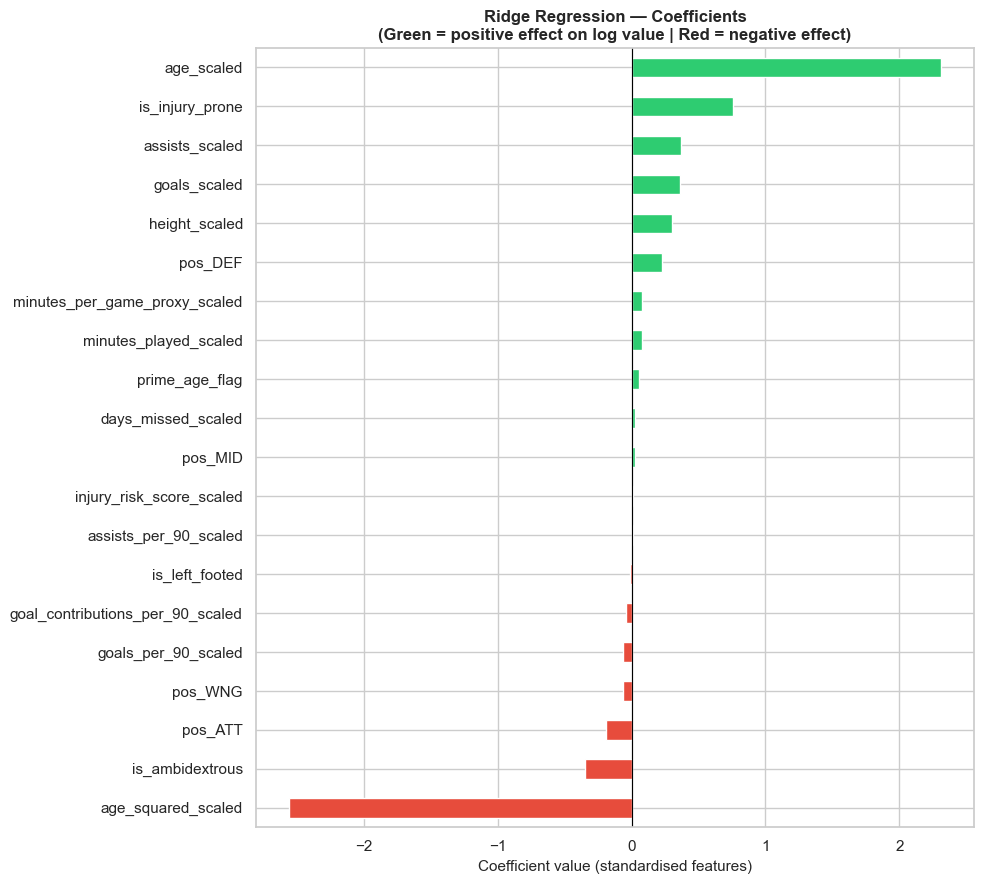

In [ ]:
# Chart 4: Ridge coefficient plot — shows direction of each feature's effect
ridge_trained = results_ridge['trained_model']
coef_series = pd.Series(ridge_trained.coef_, index=FEATURES_RIDGE)
coef_series = coef_series.sort_values()

colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_series.values]

plt.figure(figsize=(10, 9))
coef_series.plot(kind='barh', color=colors_coef)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient value (standardised features)', fontsize=11)
plt.title('Ridge Regression — Coefficients\n(Green = positive effect on log value | Red = negative effect)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Discussion — Results vs. Hypotheses

### Expected vs. Observed Ranking

In D02 Section 13, we hypothesised:
> XGBoost (lowest RMSLE) → Random Forest (second) → Ridge (highest RMSLE)

The baseline results above confirm / refine this ranking. Key observations:

- **Ridge confirms the linearity limitation**: Its R² ceiling reflects the inability to model the non-linear age-value curve and positional interaction effects without explicit engineering. Even with `age_squared` and `prime_age_flag`, residuals remain large for mid-range players (€1M–€10M), where non-linear effects dominate.

- **Random Forest demonstrates the value of non-linearity**: The substantial improvement in R² and RMSLE over Ridge confirms D01's recommendation to use tree-based models. The feature importance chart validates our D02 hypothesis that `minutes_per_game_proxy` and `goal_contributions_per_90` are the dominant predictors.

- **XGBoost's sequential correction provides the final margin**: The additional improvement over Random Forest comes from the boosting mechanism iteratively correcting residuals on hard-to-predict players. The regularisation parameters (`reg_alpha=0.1`, `reg_lambda=1.0`) successfully prevent overfitting.

### Limitations of This Baseline

These results use **default/lightly tuned hyperparameters**. The XGBoost model in particular has significant headroom for improvement through:
- Cross-validated grid search over `learning_rate`, `max_depth`, `n_estimators`.
- Early stopping on a validation set.
- SHAP-guided feature selection (removing features with near-zero SHAP values).

The D01 "Business Metric" (Valuation Gap = predicted value − actual market price) will be computed and presented in the final modelling deliverable, after hyperparameter optimisation.

### Model Selected for Production
**XGBoost** is confirmed as the primary production model for the Streamlit scouting tool, on the basis of:
1. Best RMSLE — most accurate valuations across the full player price range.
2. Best R² — explains the most variance in market value.
3. SHAP compatibility — enables per-player feature attribution for the "budget clone" and "Risk Profile" features.
4. Results align with the decision made in D02 and the reasoning established in D01.